Using low and high pass filters to design all (possible) first and second order interfaces.
Cost is 2-norm 

In [28]:
# auto reload modules
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from globalVars import *
from load_data_pickles import *
from analysis_functions import mean_and_interquartile
from plotting_variables import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0th order interface parameters

In [29]:
N_grid = 100
b0s = np.linspace(0.05,5,N_grid) 

G_find = b0s
zero_order_Gs = G_find
print(zero_order_Gs)

I_freq = zero(zero_order_Gs)  # discrete time domain
I_freq.shape

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4
 1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05 2.1
 2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75 2.8
 2.85 2.9  2.95 3.   3.05 3.1  3.15 3.2  3.25 3.3  3.35 3.4  3.45 3.5
 3.55 3.6  3.65 3.7  3.75 3.8  3.85 3.9  3.95 4.   4.05 4.1  4.15 4.2
 4.25 4.3  4.35 4.4  4.45 4.5  4.55 4.6  4.65 4.7  4.75 4.8  4.85 4.9
 4.95 5.  ]


(8, 100)

## 1st order interface parameters

In [30]:
N_grid = 100
b0s = np.linspace(0.05,5,N_grid) 
wcs = 2*np.pi*np.linspace(0.05,1,N_grid) #crossover frequency is 0.25Hz
G_find_high = []
# high pass filter: s/(s+wc)
for wc in wcs:
    for b0 in b0s:
        b1 = 0
        a0 = wc
        G_find_high.append([a0,b0,b1])
G_find_high = np.asarray(G_find_high).T
G_find_global = G_find_high
# print(G_find_global.shape)


# convert to discrete time transfer function
dt = 1./60
G_find_dis = []
for i in range(G_find_global.shape[1]):
    if np.isclose(G_find_global[1,i],G_find_global[2,i], atol=1e-14):
        pass
    else:
        a = np.array([1,G_find_global[0,i]])
        if np.isclose(G_find_global[1,i],0, atol=1e-14):
            b = np.array([G_find_global[2,i]])
        else:
            b = np.array([G_find_global[1,i],G_find_global[2,i]])
            
        num, den, dt = signal.cont2discrete((b,a),dt)
        num = num[0]
        # print(num,den)
        G_find_dis.append(np.array([den[1],num[0],num[1]])) # in discrete time domain
G_find_dis = np.asarray(G_find_dis).T
# G_find_dis.shape


# in discrete time 
# make sure the interface is stable or marginally stable
G_find_stable = []
for i in range(G_find_dis.shape[1]):
    den = np.array([1,G_find_dis[0,i]]) # 1, a0,a1
    eigenvalues = np.roots(den)
    if np.all(np.abs(eigenvalues)<=1): # stable or marginally stable
        G_find_stable.append(G_find_dis[:,i])
G_find_stable = np.asarray(G_find_stable).T
print(G_find_stable.shape) # all are stable!!

(3, 10000)


In [31]:
# representations of Higher-Order System in discrete and continuous-time can lead to different DC gain (the discretization process may cause deviations in DC gain). 
# keep the G that makes DC gain >= 0 (when z = 1), so the game is not inverted
DCgain = np.sum(G_find_stable[1:,:],axis=0) / (1 + G_find_stable[0,:]) #numerator_value / denominator_value


# this DCgain with np.sum can be slightly different with different python versions or computers (floating point), so I saved the one I used for this experiment as
G_find_sum_saved = np.loadtxt('G_find_sum_1st.txt')
DCgain_saved = G_find_sum_saved / (1 + G_find_stable[0,:])
print(np.isclose(DCgain, DCgain_saved, atol=1e-10).all())  # check if the saved DC gain is close to the calculated one here (they have rounding differences very close to 0, though)

first_order_Gs = G_find_stable[:,DCgain_saved>=0]
print(first_order_Gs.shape)
# for the paramters we used for the experiment, we have shape (3, 8546)

True
(3, 8546)


## 2nd order interface parameters

In [32]:
N_grid = 50
b0s = np.linspace(0.05,5,N_grid) 
# The cutoff should be below the frequency where the delay starts to introduce significant phase lag.
wcs = 2*np.pi*np.linspace(0.05,1,N_grid) #crossover frequency is 0.25Hz
zetas = np.linspace(0.5,1.5,N_grid) #Butterworth damping ratio

# high pass filter: s**2/(s**2 + 2*damp*wc*s + wc**2)
G_find_high = []
for wc in wcs:
    for zeta in zetas:
        for b0 in b0s:
            b1 = 0
            b2 = 0
            a0 = 2*wc*zeta
            a1 = wc**2
            G_find_high.append([a0, a1, b0, b1, b2])
G_find_high = np.asarray(G_find_high).T
G_find_global = G_find_high
# print(G_find_global.shape)

# convert to discrete time transfer function
dt = 1./60
G_find_dis = []
for i in range(G_find_global.shape[1]):
    a = np.array([1,G_find_global[0,i],G_find_global[1,i]])
    if np.isclose(G_find_global[2,i],0, atol=1e-14):
        if np.isclose(G_find_global[3,i],0, atol=1e-14):
            b = np.array([G_find_global[4,i]])
        else:
            b = np.array([G_find_global[3,i],G_find_global[4,i]])
    else:
        b = np.array([G_find_global[2,i],G_find_global[3,i],G_find_global[4,i]])
    num, den, dt = signal.cont2discrete((b,a),dt)
    num = num[0]
    G_find_dis.append(np.array([den[1],den[2],num[0],num[1],num[2]])) # in discrete time domain
G_find_dis = np.asarray(G_find_dis).T
# G_find_dis.shape

# in discrete time 
# make sure the interface is stable or marginally stable
G_find_stable = []
for i in range(G_find_dis.shape[1]):
    den = np.array([1,G_find_dis[0,i],G_find_dis[1,i]]) # 1, a0,a1
    eigenvalues = np.roots(den)
    if np.all(np.abs(eigenvalues)<=1): # stable or marginally stable
        G_find_stable.append(G_find_dis[:,i])
G_find_stable = np.asarray(G_find_stable).T
print(G_find_stable.shape) # all are stable!!

(5, 125000)


In [33]:
# representations of Higher-Order System in discrete and continuous-time can lead to different DC gain (the discretization process may cause deviations in DC gain). 
# keep the G that makes DC gain >= 0 (when z = 1), so the game is not inverted
DCgain = np.sum(G_find_stable[2:,:],axis=0) / (1 + np.sum(G_find_stable[:2,:],axis=0)) #numerator_value / denominator_value


# this DCgain with np.sum can be slightly different with different python versions or computers (floating point), so I saved the one I used for this experiment as ()
G_find_sum_saved = np.loadtxt('G_find_sum_2nd.txt') 
DCgain_saved = G_find_sum_saved / (1 + np.sum(G_find_stable[:2,:],axis=0)) 
print(np.isclose(DCgain, DCgain_saved, atol=1e-10).all()) # check if the saved DC gain is close to the calculated one here (they have rounding differences very close to 0, though)

second_order_Gs = G_find_stable[:,DCgain_saved>=0]
print(second_order_Gs.shape)
# for the paramters we used for the experiment, we have shape (5, 87038) using python=3.8.3 and numpy=1.18.5 on Windows x64, both are discontinued versions.

True
(5, 87038)


# baseline interface search (I_base) for each condition

In [34]:
# pilot subject data (N = 6) with pass-through interface (I = 1), with non-min-phase second order machine
with open(data_path+'pilot_subjects_passthrough.pkl', 'rb') as file:
    Gs_base, Hs_base, Ds_base, UHs_base, UGs_base, Ys_base, ds_base, uhs_base, ugs_base, ys_base, errors_base = pickle.load(file)

#average over all trials and subjects
H_pilot = np.mean(Hs_base, axis = (0,1))

def loss(H, G, order,lamH = 1.5,lamG = 0.5): #D = disturbance (freq); d = disturbance (time domain) shape = (2400,)
    if order=='second':
        G_ = second(G)
    elif order=='first':
        G_ = first(G)
    elif order=='zero':
        G_ = zero(G)
    else:
        print('something is wrong')
    print(G_.shape)
    D = polar2rec(amps) # D = disturbance (freq) at stim freqs        
    Y = [D[f]/(1+soM[f]*G_[f]*H[f]) for f in range(len(soM))] # when d is output disturbnace, Y = D/(1+MIH)
    Y = np.asarray(Y) #a function of G, shape = (8,100)

    # interface input and human input
    UH = [-Y[f]*H[f] for f in range(len(soM))] #U_H = -Y*H, (freq domain)
    UG = [-Y[f]*H[f]*G_[f] for f in range(len(soM))] #U_I = -Y*H*I, (freq domain)
    UH = np.asarray(UH) #a function of G, shape = (8,100)
    UG = np.asarray(UG)  #a function of G, shape = (8,100)

    # 2 norm
    losses = (np.sum(abs(Y)**2,axis=0) + lamH*np.sum(abs(UH)**2,axis=0) + lamG*np.sum(abs(UG)**2,axis=0))/np.sum(abs(D)**2,axis=0)

    return losses, Y, UH, UG

# find the interface with the smallest loss

# 0th-order 
lamH = 1.5
lamG = 0.5
losses_0th, Y_0th, UH_0th, UG_0th = loss(H_pilot[IX], zero_order_Gs, order = 'zero',lamH = lamH,lamG = lamG)
print(losses_0th.shape)
idx_min0 = np.argmin(losses_0th)
print('idx_min = ',idx_min0)
G_star0 = zero_order_Gs[idx_min0]
print('I* 0th order = ',G_star0)
print('losses_0th = ',losses_0th[idx_min0])
G_star_freq0 = zero(G_star0)

print('\n')

# 1st-order
losses_1st, Y_1st, UH_1st, UG_1st = loss(H_pilot[IX], first_order_Gs, order = 'first',lamH = lamH,lamG = lamG)
print(losses_1st.shape)
idx_min1 = np.argmin(losses_1st)
print('idx_min = ',idx_min1)
G_star1 = first_order_Gs[:,idx_min1]
print('losses_1st = ',losses_1st[idx_min1])
print('I* 1st order = ',G_star1)
G_star_freq1 = first(G_star1)

print('\n')

# 2nd-order
losses_2nd, Y_2nd, UH_2nd, UG_2nd = loss(H_pilot[IX], second_order_Gs, order = 'second',lamH = lamH,lamG = lamG)
print(losses_2nd.shape)
idx_min2 = np.argmin(losses_2nd)
print('idx_min = ',idx_min2)
G_star2 = second_order_Gs[:,idx_min2]
print('losses_2nd = ',losses_2nd[idx_min2])
print('I* 2nd order = ',G_star2)
G_star_freq2 = second(G_star2)


(8, 100)
(100,)
idx_min =  99
I* 0th order =  5.0
losses_0th =  1.3297506806646429


(8, 8546)
(8546,)
idx_min =  1536
losses_1st =  1.1047596324517108
I* 1st order =  [-0.97694596  1.55       -1.55      ]


(8, 87038)
(87038,)
idx_min =  5277
losses_2nd =  0.9661582379971853
I* 2nd order =  [-1.9886095   0.98873708  1.06020408 -2.12034041  1.06013633]


loss for 0th =  1.3297506806646429
loss for 1st =  1.1047596324517108
loss for 2nd =  0.9661582379971853




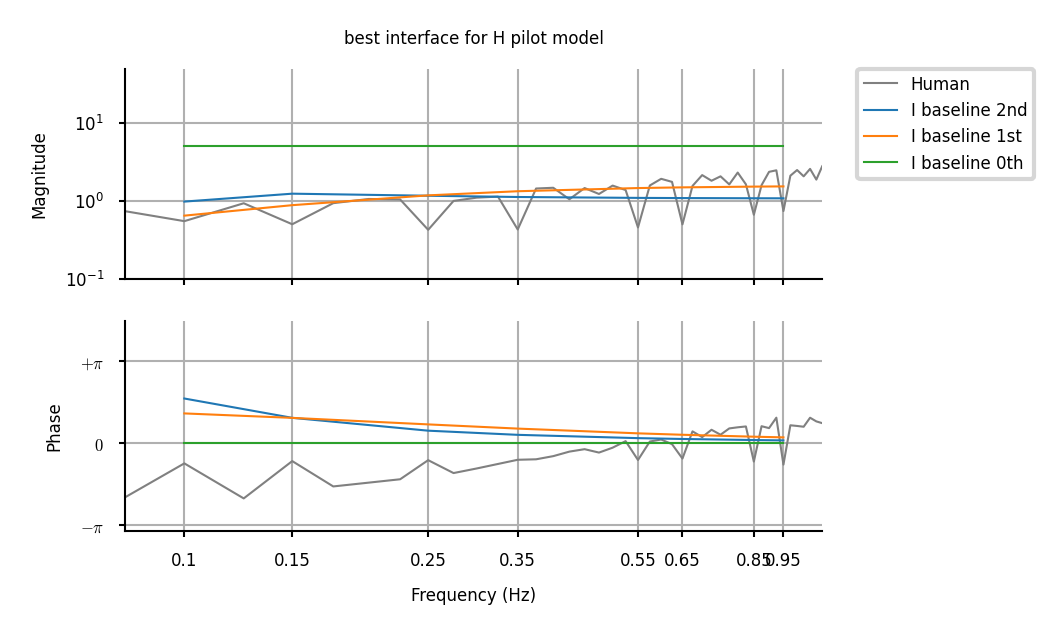

In [35]:
print('loss for 0th = ', losses_0th[idx_min0])
print('loss for 1st = ', losses_1st[idx_min1])
print('loss for 2nd = ', losses_2nd[idx_min2])
print('\n')
fig, axs = plt.subplots(2,1, figsize = (3,2),sharex = 'col', sharey = 'row',dpi = 300)
ylimphase = (-np.pi-0.2,1.5*np.pi)
yticksphase = [-np.pi,0.,np.pi]
yticklabelsphase = [r'$-\pi$',r'$0$',r'$+\pi$']
xlim = (0,21*base_freq)
xticks = primes*0.05
xticklabels =np.round(primes*0.05,2)

ax = axs[0]
ax.plot(xf, np.abs(H_pilot[:N//2]), color = 'grey',label = 'Human') # H when interface is 1 (passthough)
ax.plot(freqs, np.abs(G_star_freq2), color = python_colors[0], label = 'I baseline 2nd')
ax.plot(freqs, np.abs(G_star_freq1), color = python_colors[1], label = 'I baseline 1st')
ax.plot(freqs, np.abs(G_star_freq0), color = python_colors[2], label = 'I baseline 0th')
ax.set_ylabel('Magnitude')
ax.set_xlim(0.08,1.1)
ax.set_ylim(0.1,50)
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels,rotation=45)
ax.grid('on',zorder=-1)
ax.set_yscale("log")


ax = axs[1]
ax.plot(xf, np.angle(H_pilot[:N//2]), color = 'grey', label = 'Human')
ax.plot(freqs, np.angle(G_star_freq2), color = python_colors[0], label = 'I baseline 2nd')
ax.plot(freqs, np.angle(G_star_freq1), color = python_colors[1], label = 'I baseline 1st')
ax.plot(freqs, np.angle(G_star_freq0), color = python_colors[2], label = 'I baseline 0th')
ax.set_ylabel('Phase') 
ax.set_xlabel('Frequency (Hz)')
ax.grid('on',zorder=-1)
ax.set_ylim(ylimphase)
ax.set_yticks(yticksphase)
ax.set_yticklabels(yticklabelsphase)
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axs[0].set_title('best interface for H pilot model')
plt.show()

In [36]:
# # Save pickle file for the baseline interfaces and all parameters we used in the experiment

# Gs = [G_star0, G_star1, G_star2, zero_order_Gs, first_order_Gs, second_order_Gs]
# with open('global_search_interfaces_2norm_cost.pkl', 'wb') as file:
#     pickle.dump(Gs, file)

"""
These are the G_star0, G_star1, G_star2, zero_order_Gs, first_order_Gs, second_order_Gs saved in global_search_interfaces_2norm_cost.pkl

G_star0: 0th-order baseline interface
G_star1: 1st-order baseline interface
G_star2: 2nd-order baseline interface
zero_order_Gs: all the 0th-order interfaces we searched over
first_order_Gs: all the 1st-order interfaces we searched over that have non-negative DC gain
second_order_Gs: all the 2nd-order interfaces we searched over that have non-negative DC gain
"""

'\nThese are the G_star0, G_star1, G_star2, zero_order_Gs, first_order_Gs, second_order_Gs saved in global_search_interfaces_2norm_cost.pkl\n\nG_star0: 0th-order baseline interface\nG_star1: 1st-order baseline interface\nG_star2: 2nd-order baseline interface\nzero_order_Gs: all the 0th-order interfaces we searched over\nfirst_order_Gs: all the 1st-order interfaces we searched over that have non-negative DC gain\nsecond_order_Gs: all the 2nd-order interfaces we searched over that have non-negative DC gain\n'